In [1]:
!pip install kneed # installing knee module, will be used later
!pip install yellowbrick # installing yellowbrick module, will be used later


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip


In [2]:
from kneed import KneeLocator # used to find knee point using a function rather than manually
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_blobs # for clustering, blobs is the type of data we use, not classification or regression
from sklearn.cluster import KMeans # used to import the kmeans clustering algo
from sklearn.metrics import silhouette_score 
from yellowbrick.cluster import KElbowVisualizer

---
## <u>Generate Dataset</u>

- generally in k-means clustering we get unlabelled data but when using make_blobs we get y which shows the true value of the cluster in which a point belongs

- we dont even use y here for training or anything, we just use it to visualise properly in the graph

- the main priority is X only 

In [3]:
X, y = make_blobs(    
    n_samples=1000,
    n_features=2,
    centers=4,         # no. of centroids i.e. no. of true clusters in the data
    random_state=42,
)

X = pd.DataFrame(X)

X.head()

,0,1
0,-8.555040,7.064618
1,-6.137532,-6.580817
2,-6.321300,-6.804104
3,4.180518,1.123325
4,4.380287,0.470027


---
## <u>Visualising</u>

<Axes: xlabel='0', ylabel='1'>

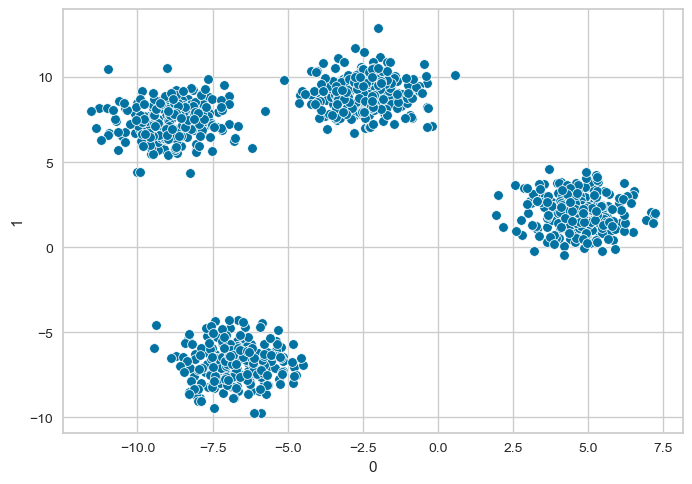

In [4]:
sns.scatterplot(
    data=X, 
    x=0,  # 1st column on x axis (this is name of columns we are passing not the number of column)
    y=1   # 2nd column on y axis (this is name of columns we are passing not the number of column)
)

# we can write the same exact things in differernt ways

# 1. using .columns functions

# sns.scatterplot(
#     data = X,
#     x = X.columns[0], (this is number of columns we are passing not the name of column)
#     y = X.columns[1]  (this is number of columns we are passing not the name of column)
# )

# 2. using .iloc function (pass only columns numbers)

# sns.scatterplot(
#     x = X.iloc[:,0],
#     y = X.iloc[:,1]
# )

# 3. using .iloc function (pass only columns names, here the name is a number only so dont get confused)

# sns.scatterplot(
#     x = X.loc[:,0],
#     y = X.loc[:,1]
# )

---
## <u>Scaling</u>
- as k means algo is based on distances between points, we always scale before training 
- we used make_blobs to generate data so no need to scale but when going to real world data, always scale for kmeans clustering

---
## <u>Create model</u>
- we dont need to train test split anymore as well cuz here we are not training the model on some data and then looking to tally the answers with our labels (y), here we train our model on all the data we have
  
- instead of .fit() and .predict() doing differently we do it together in one step as .fit_predict() because in supervised and unsupervised ML, the fundamental meaning of training was to identify patterns but in supervised we have 
a way  to test it using the predict() function and tally with labels but we cant do that for unsupervised, therefore 
we train and predict together in one go to predict nothing new but just the clusters

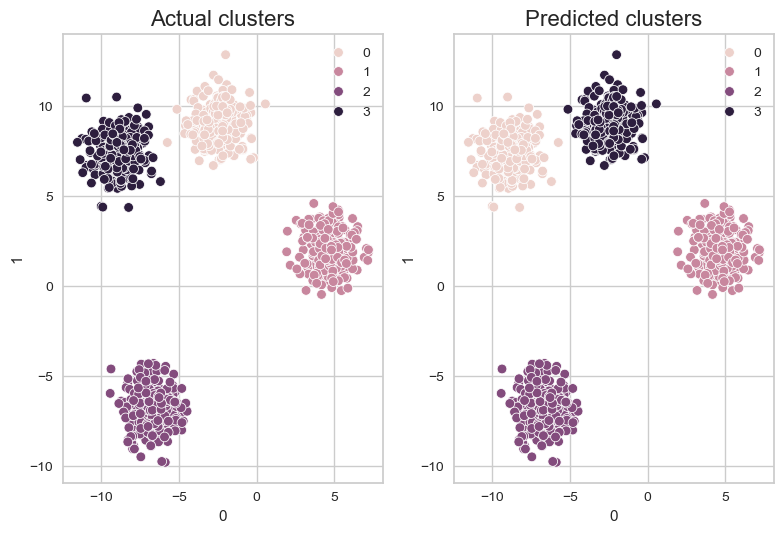

In [5]:
#  we will take a look at guided kmeans algo where we predefine/know the number of clusters

K = 4

kmeans_model = KMeans(
    n_clusters=K,
    init='k-means++',   
)

labels = kmeans_model.fit_predict(X) # labels = cluster numbers

# visualise the labels to see if the clustering was good or not

fig, ax = plt.subplots(1, 2)

# the actual clusters
sns.scatterplot(
    ax = ax[0],
    data = X,
    x = X.columns[0],
    y = X.columns[1],
    hue = y
)
ax[0].set_title("Actual clusters", fontsize = 16)

# the predicted clusters
sns.scatterplot(
    ax = ax[1],
    data = X,
    x = X.columns[0],
    y = X.columns[1],
    hue = labels
)
ax[1].set_title("Predicted clusters", fontsize = 16)


plt.tight_layout()

---
## <u>Choosing K value</u> [VERY IMP]

- we generally have 2 methods as in how to calculate K value:-  
A. Knee Method
   1. Manually
   2. Using KneeLocator
   3. Using KElbowVisualizer

Optimal K - value using KneeLocator: 4


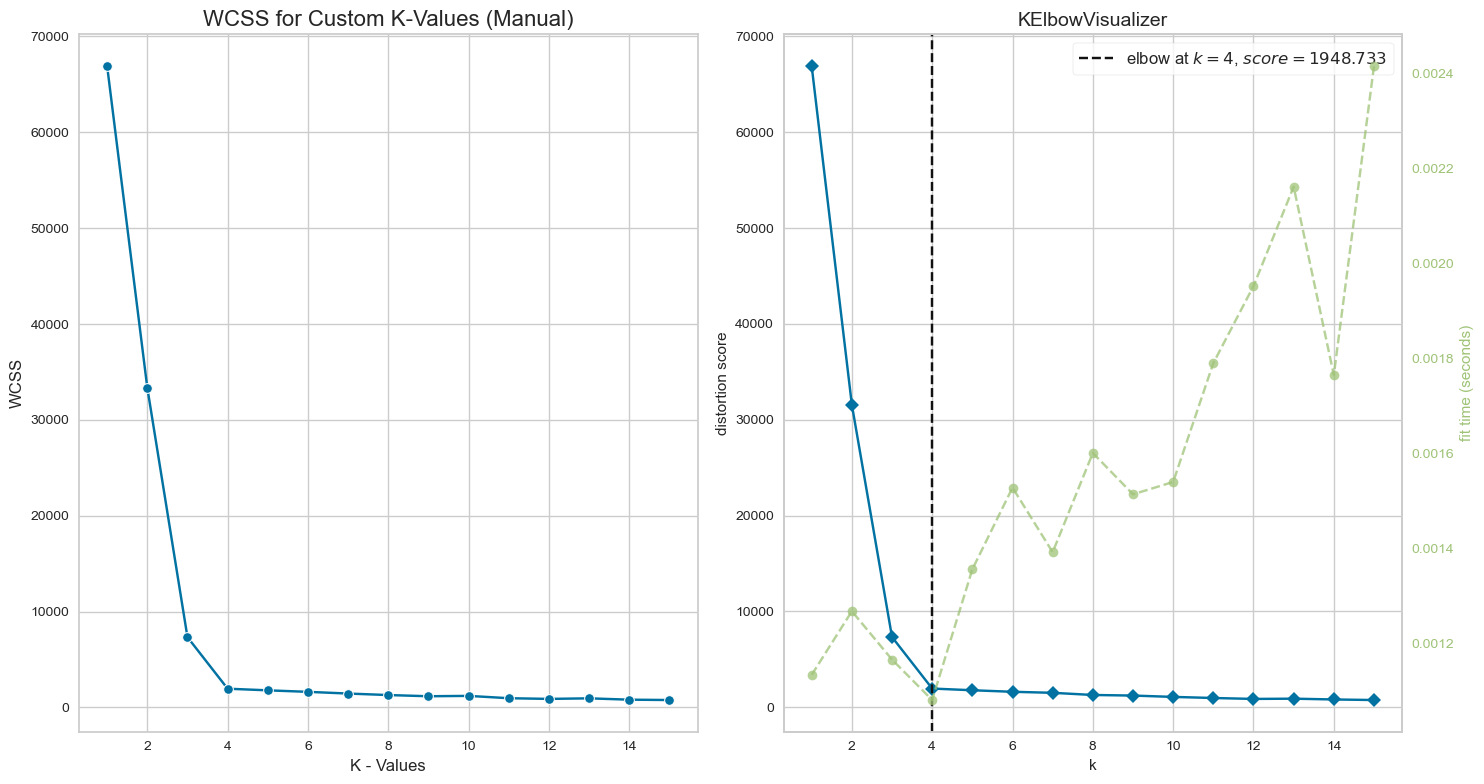

In [9]:
# define the subplots first as it will be used for KElbowVisualizer subplot
fig,ax = plt.subplots(1,2,figsize=(15,8))

# 1. Using Knee Method Manually
wcss = []
for k in range(1,16): # lets assume we want to test k values for k = 1 to k = 15
    k_means_elbow = KMeans(n_clusters = k)
    k_means_elbow.fit_predict(X)

    # the wcss value is stored in the kmeans model only, in the .intertia_ paramter
    wcss.append(k_means_elbow.inertia_)

# 2. Using Knee method via KneeLocator (find more about it at https://pypi.org/project/kneed/)
knee_point = KneeLocator(x = range(1,16), 
                         y = wcss, 
                         curve = "convex", 
                         direction = "decreasing"
)
print("Optimal K - value using KneeLocator:", knee_point.knee)

# 3. Using Knee Method via Visualizer (by yellowbrick)

visualizer = KElbowVisualizer(kmeans_model, k=(1, 16), ax = ax[1])
visualizer.fit(X) # Fit the data to the visualizer       

# plotting the graphs of knee methods (manually vs visualizer)

# manual
sns.lineplot(
    ax = ax[0],
    x = range(1,16), 
    y = wcss, 
    marker = "o"
)
ax[0].set_title("WCSS for Custom K-Values (Manual)", fontsize = 16)
ax[0].set_xlabel("K - Values", fontsize = 12)
ax[0].set_ylabel("WCSS", fontsize = 12)
ax[0].grid(True)

# KElbowVisualizer
visualizer.finalize() # finalize() instead of show() to safely attach it to ax[1]
ax[1].set_title("KElbowVisualizer", fontsize=14)

plt.tight_layout()
plt.show()

# finding : we can clearly see k = 4 is our knee point as It marks where sharp drops end and Values flatten out

#### B. Silhoutte score

Optimal k - value : 4


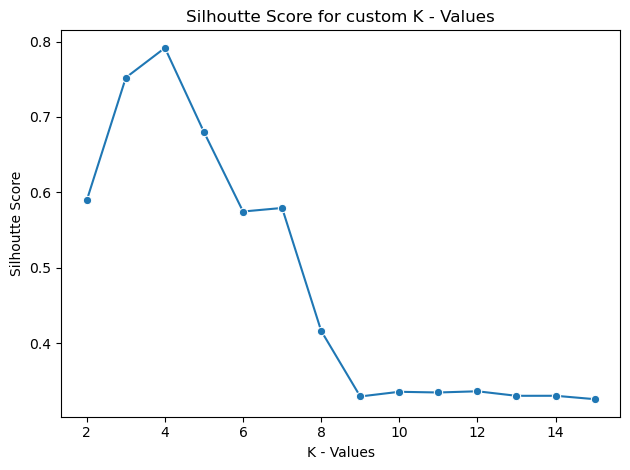

In [54]:
sil_score = []

for k in range(2, 16) : # unlike elbow method we start k - value from 2
    k_means_sil = KMeans(n_clusters=k, random_state=42) 
    labels = k_means_sil.fit_predict(X)
    score = silhouette_score(X, labels) # Calculate the silhouette score 
    sil_score.append(score)

print("Optimal k - value :", np.argmax(sil_score) + 2) # always add whatever number the range() starts with

sns.lineplot(x = range(2, 16), y = sil_score, marker = "o")
plt.title("Silhoutte Score for custom K - Values")
plt.xlabel("K - Values")
plt.ylabel("Silhoutte Score")
plt.tight_layout()
plt.grid(True)

# knee method is complex, it has a inbuilt function to calc. optimal k - value but for silhoutte score gotta do it manually
# finding : Silhoutte score is highest at k = 4, therefore optimal k value is 4